# Challenge 2 — Hacia el agua limpia para todos
## Parte 1: preparación rigurosa y línea base clásica SVM-RBF con GridSearchCV y Optuna

**Objetivo:** predecir `Potability` (`0` = no potable, `1` = potable) a partir de nueve mediciones fisicoquímicas y dejar un subconjunto **real, balanceado y congelado de 64 muestras** para la futura comparación con QSVM.

Este notebook conserva la estructura modular del notebook `track2_quantathon2026_TuQanes`, incorpora la simplicidad útil de `SVM_Quanthaton` y mantiene las buenas prácticas de auditoría y test bloqueado de `SVM-Gemini`.

### Decisión metodológica esencial

La secuencia rigurosa es:

1. Separar primero el **test original**.
2. Ajustar imputación, escalado, SMOTE y SVM exclusivamente con entrenamiento y dentro de cada fold de validación cruzada.
3. Optimizar el mismo SVM-RBF mediante dos estrategias independientes: GridSearchCV y Optuna.
4. Seleccionar el pipeline candidato usando únicamente el F1 promedio de validación cruzada.
5. Evaluar los dos candidatos sobre el test original, sin usarlo para ajustar hiperparámetros.
6. Extraer las 64 muestras cuánticas únicamente de observaciones reales del test.

> **Importante:** imputar usando la clase verdadera de una observación de test no es válido, porque esa etiqueta es precisamente lo que el modelo debe predecir. Las medianas por clase se calculan más adelante como análisis y para explicar por qué la variante anterior obtenía métricas infladas, pero la línea base reportable no usa `y_test` durante el preprocesamiento.


## 0. Fundamento matemático

Para datos binarios, una SVM busca un hiperplano con el mayor margen posible. En su formulación de margen suave:

\[
\min_{\mathbf{w},b,\boldsymbol{\xi}}
\frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^{n}\xi_i
\]

sujeto a:

\[
y_i\left(\mathbf{w}^{\top}\phi(\mathbf{x}_i)+b\right)\geq 1-\xi_i,
\qquad \xi_i\geq 0.
\]

- **`C`** controla el compromiso entre un margen amplio y penalizar errores de entrenamiento.
- El **kernel RBF** evita construir explícitamente `phi(x)` y calcula:

\[
K(\mathbf{x}_i,\mathbf{x}_j)=
\exp\left(-\gamma\|\mathbf{x}_i-\mathbf{x}_j\|^2\right).
\]

- **`gamma`** controla el alcance de influencia de cada muestra: valores grandes producen fronteras más locales y complejas; valores pequeños producen fronteras más suaves.

El RBF es razonable aquí porque las relaciones entre parámetros químicos y potabilidad pueden ser no lineales. Como el kernel depende de distancias euclidianas, la estandarización es indispensable.


## 1. Instalación e importaciones


In [1]:
#!/bin/bash
!pip install -U imbalanced-learn optuna kagglehub joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 16.9 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import json
import platform
import sys
import warnings
from pathlib import Path
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import imblearn
import optuna

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
TARGET = "Potability"
TEST_SIZE = 0.20
N_SPLITS = 5
MISSING_COLUMNS = ["ph", "Sulfate", "Trihalomethanes"]

ARTIFACT_DIR = Path("artifacts_part1")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("Optuna:", optuna.__version__)
print("Artifacts:", ARTIFACT_DIR.resolve())


Python: 3.12.13
scikit-learn: 1.6.1
imbalanced-learn: 0.14.2
Optuna: 4.9.0
Artifacts: /content/artifacts_part1


## 2. Carga robusta del dataset


In [3]:
def resolve_dataset_path() -> Path:
    """Busca el CSV localmente y, si no existe, lo descarga con KaggleHub."""
    candidates = [
        Path("/root/Downloads/water_potability.csv"),
    ]
    for path in candidates:
        if path.exists():
            return path

    try:
        import kagglehub
        dataset_dir = Path(
            kagglehub.dataset_download("adityakadiwal/water-potability")
        )
        matches = list(dataset_dir.rglob("water_potability.csv"))
        if matches:
            return matches[0]
    except Exception as exc:
        raise FileNotFoundError(
            "No se encontró water_potability.csv. Súbalo a Colab o a MyDrive."
        ) from exc

    raise FileNotFoundError("No se encontró water_potability.csv")


DATA_PATH = resolve_dataset_path()
df = pd.read_csv(DATA_PATH)

print("Archivo:", DATA_PATH)
print("Forma:", df.shape)
display(df.head())

Using Colab cache for faster access to the 'water-potability' dataset.
Archivo: /kaggle/input/water-potability/water_potability.csv
Forma: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 3. Auditoría inicial y exploración


In [4]:
EXPECTED_COLUMNS = [
    "ph", "Hardness", "Solids", "Chloramines", "Sulfate",
    "Conductivity", "Organic_carbon", "Trihalomethanes",
    "Turbidity", "Potability",
]

assert list(df.columns) == EXPECTED_COLUMNS, (
    "Las columnas no coinciden con el esquema esperado. "
    f"Recibidas: {list(df.columns)}"
)
assert df[TARGET].notna().all(), "La etiqueta contiene valores faltantes."
assert set(df[TARGET].unique()).issubset({0, 1}), "La etiqueta debe ser binaria."

missing_table = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_pct": (100 * df.isna().mean()).round(2),
    "dtype": df.dtypes.astype(str),
}).sort_values("missing", ascending=False)

class_table = pd.DataFrame({
    "count": df[TARGET].value_counts().sort_index(),
    "proportion": df[TARGET].value_counts(normalize=True).sort_index().round(4),
})

audit = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "duplicates": int(df.duplicated().sum()),
    "missing": {k: int(v) for k, v in df.isna().sum().items()},
    "class_counts": {str(k): int(v) for k, v in df[TARGET].value_counts().items()},
}

print(json.dumps(audit, indent=2, ensure_ascii=False))
display(missing_table)
display(class_table)

{
  "rows": 3276,
  "columns": 10,
  "duplicates": 0,
  "missing": {
    "ph": 491,
    "Hardness": 0,
    "Solids": 0,
    "Chloramines": 0,
    "Sulfate": 781,
    "Conductivity": 0,
    "Organic_carbon": 0,
    "Trihalomethanes": 162,
    "Turbidity": 0,
    "Potability": 0
  },
  "class_counts": {
    "0": 1998,
    "1": 1278
  }
}


,missing,missing_pct,dtype
Sulfate,781,23.84,float64
ph,491,14.99,float64
Trihalomethanes,162,4.95,float64
Hardness,0,0.00,float64
Chloramines,0,0.00,float64
Solids,0,0.00,float64
Conductivity,0,0.00,float64
Organic_carbon,0,0.00,float64
Turbidity,0,0.00,float64
Potability,0,0.00,int64


,count,proportion
Potability,,
0,1998,0.6099
1,1278,0.3901


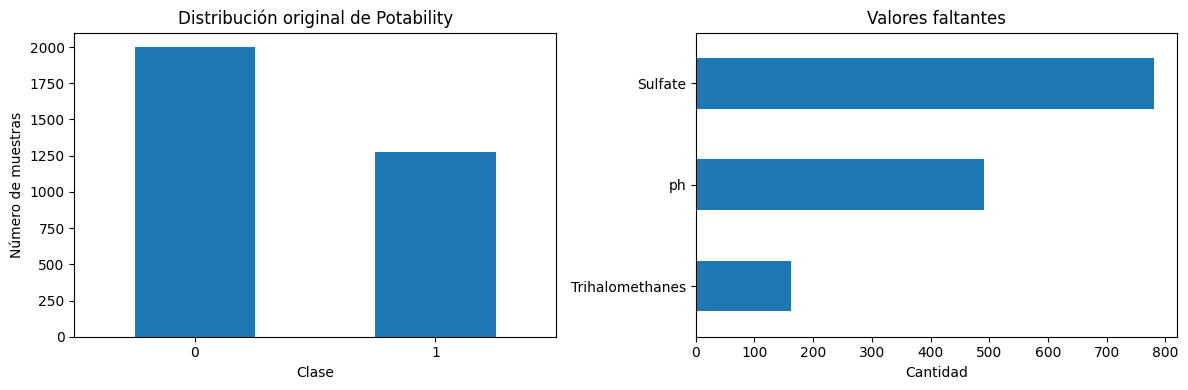

In [5]:
# Distribución de clases y variables.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[TARGET].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Distribución original de Potability")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Número de muestras")
axes[0].tick_params(axis="x", rotation=0)

missing_table.loc[missing_table["missing"] > 0, "missing"].sort_values().plot(
    kind="barh", ax=axes[1]
)
axes[1].set_title("Valores faltantes")
axes[1].set_xlabel("Cantidad")

plt.tight_layout()
plt.show()

### Lectura esperada

- El dataset contiene 3,276 observaciones, nueve variables predictoras y una etiqueta.
- La clase `0` es mayoritaria y representa aproximadamente 61%.
- Los faltantes se concentran en `ph`, `Sulfate` y `Trihalomethanes`.
- Las métricas deben interpretarse para la clase positiva `1 = potable`, sin perder de vista la matriz de confusión completa.


## 4. Split estratificado original y test bloqueado


In [6]:
X = df.drop(columns=TARGET)
y = df[TARGET].astype(int)

train_indices, test_indices = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED,
)

X_train = X.loc[train_indices].copy()
X_test = X.loc[test_indices].copy()
y_train = y.loc[train_indices].copy()
y_test = y.loc[test_indices].copy()

assert set(X_train.index).isdisjoint(X_test.index)
assert len(X_train) + len(X_test) == len(df)

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "n": [len(y_train), len(y_test)],
    "class_0": [(y_train == 0).sum(), (y_test == 0).sum()],
    "class_1": [(y_train == 1).sum(), (y_test == 1).sum()],
    "positive_pct": [100 * y_train.mean(), 100 * y_test.mean()],
})

display(split_summary)

# Se guarda el test original antes de imputar, escalar o aplicar SMOTE.
test_locked = X_test.copy()
test_locked.insert(0, "source_index", test_locked.index)
test_locked[TARGET] = y_test

test_locked.to_csv(ARTIFACT_DIR / "test_locked_original.csv", index=False)
print("Test bloqueado guardado.")

,split,n,class_0,class_1,positive_pct
0,train,2620,1598,1022,39.007634
1,test,656,400,256,39.024390


Test bloqueado guardado.


## 5. Medianas por clase: análisis solicitado y límite metodológico

Las siguientes medianas se calculan **solo sobre entrenamiento**. Son útiles para entender las clases y reproducir una ablación, pero no se usan para rellenar el test con su etiqueta real.

Usar `y_test` para escoger la mediana revelaría indirectamente la respuesta correcta al preprocesamiento. Además, en producción no existe una etiqueta verdadera disponible antes de predecir.


In [7]:
train_with_target = X_train.copy()
train_with_target[TARGET] = y_train

class_medians = (
    train_with_target
    .groupby(TARGET)[MISSING_COLUMNS]
    .median()
    .T
    .rename(columns={0: "median_non_potable", 1: "median_potable"})
)
class_medians["absolute_difference"] = (
    class_medians["median_potable"] - class_medians["median_non_potable"]
).abs()

display(class_medians)
class_medians.to_csv(ARTIFACT_DIR / "training_class_medians.csv")

Potability,median_non_potable,median_potable,absolute_difference
ph,7.013540,7.063647,0.050107
Sulfate,333.148318,332.936375,0.211943
Trihalomethanes,66.284819,66.686093,0.401274


In [8]:
def impute_training_by_class(
    X_part: pd.DataFrame,
    y_part: pd.Series,
    columns: list[str] = MISSING_COLUMNS,
) -> pd.DataFrame:
    """
    Ablación supervisada: rellena SOLO datos de entrenamiento usando y_train.
    No debe llamarse con y_test ni con etiquetas futuras.
    """
    joined = X_part.copy()
    joined[TARGET] = y_part
    for column in columns:
        joined[column] = joined[column].fillna(
            joined.groupby(TARGET)[column].transform("median")
        )
    return joined.drop(columns=TARGET)


X_train_class_imputed = impute_training_by_class(X_train, y_train)
assert X_train_class_imputed[MISSING_COLUMNS].isna().sum().sum() == 0
print("Ablación por clase preparada solo para TRAIN:", X_train_class_imputed.shape)
print("No se utiliza y_test para imputar.")

Ablación por clase preparada solo para TRAIN: (2620, 9)
No se utiliza y_test para imputar.


### Estrategia reportable

La línea base final usa una mediana aprendida únicamente de la partición de entrenamiento de cada fold. Esto garantiza que:

- no se use la etiqueta del test;
- no se calculen estadísticas con el fold de validación;
- el mismo transformador pueda operar en datos nuevos sin conocer su clase.

La ablación por clase queda documentada al final para explicar por qué puede producir cifras artificialmente mayores si se aplica antes del split.


## 6. Optimización 1: GridSearchCV sobre el pipeline completo


In [9]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)

pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    # SMOTE se aplica únicamente durante fit. El test nunca se sobremuestrea.
    ("smote", SMOTE(
        sampling_strategy=1.0,
        random_state=SEED,
        k_neighbors=5,
    )),
    ("svc", SVC(
        kernel="rbf",
        probability=False,
        cache_size=1000,
        random_state=SEED,
    )),
])

param_grid = {
    # Rango logarítmico solicitado para C.
    "svc__C": np.logspace(-2, 2, 5),  # 0.01, 0.1, 1, 10, 100
    "svc__gamma": ["scale", "auto", 0.01],
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy",
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
    verbose=1,
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor F1 promedio en CV:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Mejores hiperparámetros: {'svc__C': np.float64(1.0), 'svc__gamma': 'auto'}
Mejor F1 promedio en CV: 0.574


In [10]:
# Tabla compacta de validación cruzada.
cv_results = pd.DataFrame(grid_search.cv_results_)
columns_to_show = [
    "param_svc__C",
    "param_svc__gamma",
    "mean_test_f1",
    "std_test_f1",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_accuracy",
    "mean_test_balanced_accuracy",
]

cv_top = (
    cv_results[columns_to_show]
    .sort_values("mean_test_f1", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(cv_top)
cv_top.to_csv(ARTIFACT_DIR / "cv_top_results.csv", index=False)

,param_svc__C,param_svc__gamma,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall,mean_test_accuracy,mean_test_balanced_accuracy
0,1.00,auto,0.574043,0.024690,0.534973,0.622224,0.641221,0.637741
1,1.00,scale,0.573286,0.025504,0.535171,0.620268,0.641221,0.637388
2,100.00,0.01,0.562802,0.024974,0.516584,0.621282,0.624809,0.624129
3,10.00,auto,0.560520,0.019510,0.532965,0.593855,0.637786,0.629819
4,10.00,scale,0.559551,0.020035,0.531868,0.592874,0.637023,0.629016
5,0.01,scale,0.531369,0.037022,0.475575,0.605705,0.582061,0.586308
6,100.00,auto,0.530442,0.033421,0.515579,0.547877,0.622901,0.609337
7,10.00,0.01,0.530260,0.046533,0.509051,0.560607,0.617557,0.607243
8,0.01,auto,0.527551,0.041876,0.474392,0.597896,0.581298,0.584279
9,0.10,scale,0.527206,0.034128,0.501782,0.558670,0.610687,0.601265


## 7. Optimización 2: búsqueda bayesiana con Optuna

Optuna utiliza un muestreador **TPE (Tree-structured Parzen Estimator)** para concentrar progresivamente los ensayos en regiones prometedoras del espacio de hiperparámetros.

Para mantener una comparación justa:

- se reutilizan exactamente `X_train`, `y_train` y los mismos cinco folds estratificados;
- el pipeline sigue siendo `imputación → StandardScaler → SMOTE → SVM-RBF`;
- solo se optimizan `C` y `gamma`;
- el objetivo continúa siendo el **F1 de la clase potable**;
- el conjunto de prueba no participa en ningún ensayo;
- la poda se basa únicamente en resultados parciales de los folds de entrenamiento.

El espacio de búsqueda de Optuna es más fino que la cuadrícula: `C` se explora logarítmicamente y `gamma` puede ser `scale`, `auto` o un valor numérico optimizado en escala logarítmica.


In [11]:
N_OPTUNA_TRIALS = 40


def optuna_objective(trial: optuna.Trial) -> float:
    """Maximiza el F1 medio de cinco folds, sin tocar el test."""
    C = trial.suggest_float("C", 1e-3, 1e3, log=True)
    gamma_strategy = trial.suggest_categorical(
        "gamma_strategy",
        ["scale", "auto", "optimized_numeric"],
    )

    if gamma_strategy == "optimized_numeric":
        gamma = trial.suggest_float("gamma_numeric", 1e-4, 1e1, log=True)
    else:
        gamma = gamma_strategy

    candidate = clone(pipeline).set_params(
        svc__C=C,
        svc__gamma=gamma,
    )

    fold_f1_scores = []
    for fold_number, (fold_train_pos, fold_valid_pos) in enumerate(
        cv.split(X_train, y_train),
        start=1,
    ):
        X_fold_train = X_train.iloc[fold_train_pos]
        X_fold_valid = X_train.iloc[fold_valid_pos]
        y_fold_train = y_train.iloc[fold_train_pos]
        y_fold_valid = y_train.iloc[fold_valid_pos]

        fold_model = clone(candidate)
        fold_model.fit(X_fold_train, y_fold_train)
        fold_pred = fold_model.predict(X_fold_valid)

        fold_f1 = f1_score(
            y_fold_valid,
            fold_pred,
            pos_label=1,
            zero_division=0,
        )
        fold_f1_scores.append(fold_f1)

        running_mean = float(np.mean(fold_f1_scores))
        trial.report(running_mean, step=fold_number)
        if trial.should_prune():
            raise optuna.TrialPruned()

    trial.set_user_attr("resolved_gamma", gamma)
    return float(np.mean(fold_f1_scores))


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2,
    ),
    study_name="water_potability_svm_rbf",
)

study.optimize(
    optuna_objective,
    n_trials=N_OPTUNA_TRIALS,
    show_progress_bar=True,
)

optuna_best_gamma = study.best_trial.user_attrs["resolved_gamma"]
optuna_best_params = {
    "svc__C": float(study.best_trial.params["C"]),
    "svc__gamma": optuna_best_gamma,
}

optuna_best_model = clone(pipeline).set_params(**optuna_best_params)
optuna_best_model.fit(X_train, y_train)

print("Mejor ensayo:", study.best_trial.number)
print("Mejores hiperparámetros Optuna:", optuna_best_params)
print("Mejor F1 promedio en CV:", round(study.best_value, 4))

optuna_trials = study.trials_dataframe()
optuna_trials.to_csv(
    ARTIFACT_DIR / "optuna_all_trials.csv",
    index=False,
)

display(
    optuna_trials
    .query("state == 'COMPLETE'")
    .sort_values("value", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

search_cv_comparison = pd.DataFrame({
    "optimizer": ["GridSearchCV", "Optuna"],
    "best_cv_f1": [grid_search.best_score_, study.best_value],
    "best_C": [
        float(grid_search.best_params_["svc__C"]),
        float(optuna_best_params["svc__C"]),
    ],
    "best_gamma": [
        str(grid_search.best_params_["svc__gamma"]),
        str(optuna_best_params["svc__gamma"]),
    ],
}).sort_values("best_cv_f1", ascending=False)

display(search_cv_comparison.round(6))
search_cv_comparison.to_csv(
    ARTIFACT_DIR / "optimizer_cv_comparison.csv",
    index=False,
)

# La elección se hace SOLO con CV de entrenamiento, nunca con el test.
if study.best_value > grid_search.best_score_:
    selected_model = optuna_best_model
    selected_optimizer = "Optuna"
    selected_cv_f1 = float(study.best_value)
else:
    selected_model = best_model
    selected_optimizer = "GridSearchCV"
    selected_cv_f1 = float(grid_search.best_score_)

print("Pipeline seleccionado por CV:", selected_optimizer)
print("F1 CV del pipeline seleccionado:", round(selected_cv_f1, 4))


[I 2026-07-21 05:06:25,611] A new study created in memory with name: water_potability_svm_rbf


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-07-21 05:06:27,594] Trial 0 finished with value: 0.5418781177179314 and parameters: {'C': 0.1767016940294795, 'gamma_strategy': 'scale'}. Best is trial 0 with value: 0.5418781177179314.
[I 2026-07-21 05:06:29,673] Trial 1 finished with value: 0.5195847331511498 and parameters: {'C': 0.008632008168602538, 'gamma_strategy': 'optimized_numeric', 'gamma_numeric': 0.10129197956845731}. Best is trial 0 with value: 0.5418781177179314.
[I 2026-07-21 05:06:33,531] Trial 2 finished with value: 0.5540112590568456 and parameters: {'C': 17.71884735480682, 'gamma_strategy': 'auto'}. Best is trial 2 with value: 0.5540112590568456.
[I 2026-07-21 05:06:35,958] Trial 3 finished with value: 0.35784229465248885 and parameters: {'C': 0.018794668241638456, 'gamma_strategy': 'optimized_numeric', 'gamma_numeric': 0.042051564509138675}. Best is trial 2 with value: 0.5540112590568456.
[I 2026-07-21 05:06:37,820] Trial 4 finished with value: 0.5659081959590484 and parameters: {'C': 0.3905441275210791, 'g

,number,value,datetime_start,datetime_complete,duration,params_C,params_gamma_numeric,params_gamma_strategy,user_attrs_resolved_gamma,state
0,31,0.577310,2026-07-21 05:07:34.336469,2026-07-21 05:07:36.182916,0 days 00:00:01.846447,1.495122,NaN,auto,auto,COMPLETE
1,36,0.577298,2026-07-21 05:07:42.854929,2026-07-21 05:07:44.653799,0 days 00:00:01.798870,1.489705,NaN,auto,auto,COMPLETE
2,21,0.577096,2026-07-21 05:07:17.927226,2026-07-21 05:07:19.700960,0 days 00:00:01.773734,0.648980,NaN,auto,auto,COMPLETE
3,22,0.576653,2026-07-21 05:07:19.705045,2026-07-21 05:07:21.490144,0 days 00:00:01.785099,1.165128,NaN,auto,auto,COMPLETE
4,27,0.576099,2026-07-21 05:07:28.236774,2026-07-21 05:07:30.055093,0 days 00:00:01.818319,1.673795,NaN,auto,auto,COMPLETE
5,13,0.574622,2026-07-21 05:07:00.574433,2026-07-21 05:07:02.527833,0 days 00:00:01.953400,1.921352,NaN,auto,auto,COMPLETE
6,15,0.574121,2026-07-21 05:07:04.309890,2026-07-21 05:07:06.177554,0 days 00:00:01.867664,2.056094,NaN,auto,auto,COMPLETE
7,37,0.572935,2026-07-21 05:07:44.658190,2026-07-21 05:07:46.428319,0 days 00:00:01.770129,0.535591,NaN,auto,auto,COMPLETE
8,25,0.572315,2026-07-21 05:07:24.114105,2026-07-21 05:07:27.096811,0 days 00:00:02.982706,0.596920,NaN,auto,auto,COMPLETE
9,14,0.571512,2026-07-21 05:07:02.532563,2026-07-21 05:07:04.305762,0 days 00:00:01.773199,0.928679,NaN,auto,auto,COMPLETE


,optimizer,best_cv_f1,best_C,best_gamma
1,Optuna,0.577310,1.495122,auto
0,GridSearchCV,0.574043,1.000000,auto


Pipeline seleccionado por CV: Optuna
F1 CV del pipeline seleccionado: 0.5773


## 8. Comprobación de balanceo solo en entrenamiento


In [12]:
# Auditoría del conjunto que ve la SVM final.
X_train_imputed = selected_model.named_steps["imputer"].transform(X_train)
X_train_scaled = selected_model.named_steps["scaler"].transform(X_train_imputed)
X_train_balanced, y_train_balanced = selected_model.named_steps["smote"].fit_resample(
    X_train_scaled, y_train
)

print("Antes de SMOTE:", Counter(y_train))
print("Después de SMOTE:", Counter(y_train_balanced))
print("Test original:", Counter(y_test))

assert Counter(y_train_balanced)[0] == Counter(y_train_balanced)[1]
assert len(y_test) == len(test_locked)


Antes de SMOTE: Counter({0: 1598, 1: 1022})
Después de SMOTE: Counter({0: 1598, 1: 1598})
Test original: Counter({0: 400, 1: 256})


## 9. Evaluación única en el test original


,value
accuracy,0.6143
precision_potable,0.5056
recall_potable,0.5273
f1_potable,0.5163
balanced_accuracy,0.5987
roc_auc,0.6480


                precision    recall  f1-score   support

No potable (0)     0.6889    0.6700    0.6793       400
   Potable (1)     0.5056    0.5273    0.5163       256

      accuracy                         0.6143       656
     macro avg     0.5973    0.5987    0.5978       656
  weighted avg     0.6174    0.6143    0.6157       656



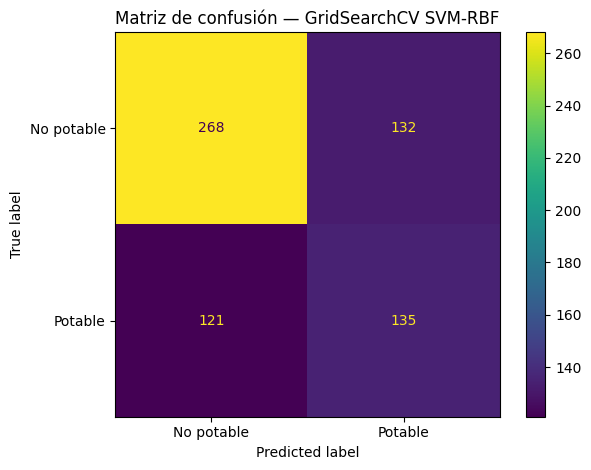

In [13]:
y_pred = best_model.predict(X_test)
y_score = best_model.decision_function(X_test)

metrics_default = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_potable": precision_score(y_test, y_pred, zero_division=0),
    "recall_potable": recall_score(y_test, y_pred, zero_division=0),
    "f1_potable": f1_score(y_test, y_pred, zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_score),
}

metrics_default_df = pd.DataFrame.from_dict(
    metrics_default, orient="index", columns=["value"]
)
display(metrics_default_df.round(4))

print(classification_report(
    y_test,
    y_pred,
    target_names=["No potable (0)", "Potable (1)"],
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No potable", "Potable"],
)
disp.plot(values_format="d")
plt.title("Matriz de confusión — GridSearchCV SVM-RBF")
plt.tight_layout()
plt.show()

metrics_default_df.to_csv(ARTIFACT_DIR / "test_metrics_default_threshold.csv")


### 9.1 Evaluación adicional del SVM-RBF optimizado con Optuna

Los dos modelos se evalúan con las mismas observaciones del test bloqueado. Esta comparación sirve para cuantificar la estabilidad de las dos estrategias de optimización, pero **el modelo seleccionado ya fue decidido previamente por F1 de validación cruzada**. No se cambia el ganador después de observar el test.


,GridSearchCV,Optuna
accuracy,0.6143,0.6128
precision_potable,0.5056,0.5038
recall_potable,0.5273,0.5156
f1_potable,0.5163,0.5097
balanced_accuracy,0.5987,0.5953
roc_auc,0.6480,0.6475


Reporte de clasificación — Optuna
                precision    recall  f1-score   support

No potable (0)     0.6853    0.6750    0.6801       400
   Potable (1)     0.5038    0.5156    0.5097       256

      accuracy                         0.6128       656
     macro avg     0.5945    0.5953    0.5949       656
  weighted avg     0.6145    0.6128    0.6136       656



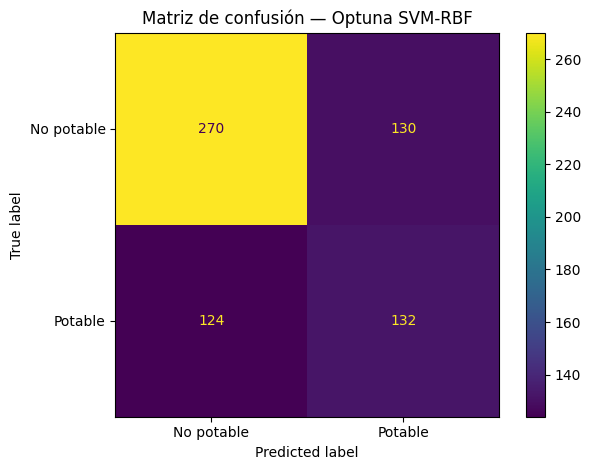

Modelo usado en las etapas posteriores: Optuna


In [14]:
y_pred_optuna = optuna_best_model.predict(X_test)
y_score_optuna = optuna_best_model.decision_function(X_test)

metrics_optuna = {
    "accuracy": accuracy_score(y_test, y_pred_optuna),
    "precision_potable": precision_score(
        y_test, y_pred_optuna, zero_division=0
    ),
    "recall_potable": recall_score(
        y_test, y_pred_optuna, zero_division=0
    ),
    "f1_potable": f1_score(
        y_test, y_pred_optuna, zero_division=0
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_test, y_pred_optuna
    ),
    "roc_auc": roc_auc_score(y_test, y_score_optuna),
}

optimizer_test_comparison = pd.DataFrame({
    "GridSearchCV": metrics_default,
    "Optuna": metrics_optuna,
})

display(optimizer_test_comparison.round(4))
optimizer_test_comparison.to_csv(
    ARTIFACT_DIR / "optimizer_test_comparison.csv"
)

print("Reporte de clasificación — Optuna")
print(classification_report(
    y_test,
    y_pred_optuna,
    target_names=["No potable (0)", "Potable (1)"],
    digits=4,
    zero_division=0,
))

cm_optuna = confusion_matrix(y_test, y_pred_optuna)
disp_optuna = ConfusionMatrixDisplay(
    confusion_matrix=cm_optuna,
    display_labels=["No potable", "Potable"],
)
disp_optuna.plot(values_format="d")
plt.title("Matriz de confusión — Optuna SVM-RBF")
plt.tight_layout()
plt.show()

pd.DataFrame.from_dict(
    metrics_optuna,
    orient="index",
    columns=["value"],
).to_csv(ARTIFACT_DIR / "test_metrics_optuna.csv")

if selected_optimizer == "Optuna":
    y_pred_selected = y_pred_optuna
    y_score_selected = y_score_optuna
    metrics_selected_default = metrics_optuna
else:
    y_pred_selected = y_pred
    y_score_selected = y_score
    metrics_selected_default = metrics_default

print("Modelo usado en las etapas posteriores:", selected_optimizer)


### Cómo interpretar las métricas

- **Accuracy:** porcentaje total de predicciones correctas. Puede ocultar problemas si una clase domina.
- **Precision de potable:** de todas las muestras predichas como potables, qué fracción realmente lo era. Una precisión baja implica riesgo de declarar potable agua no potable.
- **Recall de potable:** de todas las muestras realmente potables, qué fracción detectó el modelo.
- **F1:** media armónica entre precision y recall; es la métrica principal solicitada.
- **Matriz de confusión:**
  - `TN`: no potable correctamente detectada;
  - `FP`: no potable clasificada como potable — error especialmente sensible en seguridad;
  - `FN`: potable clasificada como no potable;
  - `TP`: potable correctamente detectada.

Un F1 inferior a 0.60 en un test limpio no debe ocultarse. En este dataset hay gran solapamiento entre clases; una cifra menor pero honesta es preferible a una cifra elevada por fuga de información.


## 10. Ajuste opcional del umbral usando solo entrenamiento


In [15]:
# La SVM usa 0 como umbral predeterminado de decision_function.
# Aquí se obtiene un umbral alternativo con predicciones out-of-fold de TRAIN.
# Este paso es válido porque el test no participa en la selección.

oof_scores = cross_val_predict(
    selected_model,
    X_train,
    y_train,
    cv=cv,
    method="decision_function",
    n_jobs=-1,
)

threshold_grid = np.linspace(
    np.percentile(oof_scores, 1),
    np.percentile(oof_scores, 99),
    401,
)

threshold_results = pd.DataFrame({
    "threshold": threshold_grid,
    "f1": [
        f1_score(y_train, (oof_scores >= t).astype(int), zero_division=0)
        for t in threshold_grid
    ],
})

best_threshold = float(
    threshold_results.loc[threshold_results["f1"].idxmax(), "threshold"]
)
print("Optimizador del pipeline:", selected_optimizer)
print("Umbral seleccionado con OOF train:", round(best_threshold, 6))
print("F1 OOF asociado:", round(threshold_results["f1"].max(), 4))

# Aplicación única al test.
y_pred_tuned = (y_score_selected >= best_threshold).astype(int)

metrics_tuned = {
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision_potable": precision_score(y_test, y_pred_tuned, zero_division=0),
    "recall_potable": recall_score(y_test, y_pred_tuned, zero_division=0),
    "f1_potable": f1_score(y_test, y_pred_tuned, zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_tuned),
    "roc_auc": roc_auc_score(y_test, y_score_selected),
}

display(pd.DataFrame({
    "default_threshold": metrics_selected_default,
    "cv_tuned_threshold": metrics_tuned,
}).round(4))


Optimizador del pipeline: Optuna
Umbral seleccionado con OOF train: -0.401075
F1 OOF asociado: 0.6043


,default_threshold,cv_tuned_threshold
accuracy,0.6128,0.5732
precision_potable,0.5038,0.4701
recall_potable,0.5156,0.7383
f1_potable,0.5097,0.5745
balanced_accuracy,0.5953,0.6029
roc_auc,0.6475,0.6475


> Para la futura comparación clásica–cuántica, debe decidirse por adelantado si ambos modelos usarán el umbral por defecto o si ambos tendrán un umbral ajustado con entrenamiento. No conviene favorecer únicamente a uno de los dos.


## 11. Subconjunto cuántico: 64 muestras reales, 32 + 32


In [ ]:
# Muestreo explícito por clase desde el test original.
idx_non_potable = y_test[y_test == 0].sample(
    n=32, random_state=SEED
).index
idx_potable = y_test[y_test == 1].sample(
    n=32, random_state=SEED
).index

quantum_indices = np.concatenate([
    idx_non_potable.to_numpy(),
    idx_potable.to_numpy(),
])

# Barajar manteniendo reproducibilidad.
rng = np.random.default_rng(SEED)
rng.shuffle(quantum_indices)

X_quantum_raw = X_test.loc[quantum_indices].copy()
y_quantum_subset = y_test.loc[quantum_indices].to_numpy(dtype=int)

# Se aplican solo los transformadores aprendidos del modelo clásico.
# SMOTE NO se aplica al subconjunto cuántico.
X_quantum_imputed = selected_model.named_steps["imputer"].transform(X_quantum_raw)
X_quantum_subset = selected_model.named_steps["scaler"].transform(X_quantum_imputed)

assert X_quantum_subset.shape == (64, X.shape[1])
assert np.bincount(y_quantum_subset, minlength=2).tolist() == [32, 32]
assert set(quantum_indices).issubset(set(X_test.index))
assert len(np.unique(quantum_indices)) == 64

print("X_quantum_subset:", X_quantum_subset.shape)
print("y_quantum_subset:", y_quantum_subset.shape)
print("Balance:", np.bincount(y_quantum_subset, minlength=2))


In [ ]:
# Guardado legible y binario.
quantum_raw_export = X_quantum_raw.copy()
quantum_raw_export.insert(0, "source_index", quantum_raw_export.index)
quantum_raw_export[TARGET] = y_quantum_subset
quantum_raw_export.to_csv(
    ARTIFACT_DIR / "quantum_subset_64_raw.csv", index=False
)

quantum_scaled_export = pd.DataFrame(
    X_quantum_subset,
    columns=X.columns,
)
quantum_scaled_export.insert(0, "source_index", quantum_indices)
quantum_scaled_export[TARGET] = y_quantum_subset
quantum_scaled_export.to_csv(
    ARTIFACT_DIR / "quantum_subset_64_scaled.csv", index=False
)

np.savez_compressed(
    ARTIFACT_DIR / "quantum_subset_64.npz",
    X=X_quantum_subset,
    y=y_quantum_subset,
    source_indices=quantum_indices,
    feature_names=np.array(X.columns, dtype=object),
)

joblib.dump(
    best_model,
    ARTIFACT_DIR / "svm_rbf_gridsearch_pipeline.joblib",
)
joblib.dump(
    optuna_best_model,
    ARTIFACT_DIR / "svm_rbf_optuna_pipeline.joblib",
)
joblib.dump(
    selected_model,
    ARTIFACT_DIR / "svm_rbf_selected_pipeline.joblib",
)

metadata = {
    "seed": SEED,
    "test_size": TEST_SIZE,
    "cv_folds": N_SPLITS,
    "gridsearch_best_params": {
        k: (v.item() if hasattr(v, "item") else v)
        for k, v in grid_search.best_params_.items()
    },
    "gridsearch_best_cv_f1": float(grid_search.best_score_),
    "optuna_trials": N_OPTUNA_TRIALS,
    "optuna_best_trial": int(study.best_trial.number),
    "optuna_best_params": {
        "svc__C": float(optuna_best_params["svc__C"]),
        "svc__gamma": (
            float(optuna_best_params["svc__gamma"])
            if isinstance(
                optuna_best_params["svc__gamma"],
                (int, float, np.floating),
            )
            else str(optuna_best_params["svc__gamma"])
        ),
    },
    "optuna_best_cv_f1": float(study.best_value),
    "selected_optimizer": selected_optimizer,
    "selected_cv_f1": selected_cv_f1,
    "gridsearch_test_metrics": {
        k: float(v) for k, v in metrics_default.items()
    },
    "optuna_test_metrics": {
        k: float(v) for k, v in metrics_optuna.items()
    },
    "selected_default_test_metrics": {
        k: float(v) for k, v in metrics_selected_default.items()
    },
    "tuned_threshold": best_threshold,
    "tuned_test_metrics": {k: float(v) for k, v in metrics_tuned.items()},
    "quantum_subset_size": 64,
    "quantum_class_counts": [32, 32],
    "python": sys.version.split()[0],
    "sklearn": sklearn.__version__,
    "imblearn": imblearn.__version__,
    "optuna": optuna.__version__,
}

with open(ARTIFACT_DIR / "run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Artefactos generados:")
for path in sorted(ARTIFACT_DIR.iterdir()):
    print(" -", path)


## 12. Ablación: por qué no se reporta SMOTE antes del split

El siguiente patrón **no debe usarse para el resultado oficial**:

```python
# NO REPORTAR: fuga de información
for col in MISSING_COLUMNS:
    df[col] = df[col].fillna(
        df.groupby("Potability")[col].transform("median")
    )
X_balanced, y_balanced = SMOTE().fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced)
```

Problemas:

1. La imputación usa la etiqueta de todas las filas, incluido el futuro test.
2. SMOTE ve todo el dataset y genera puntos antes de separar train/test.
3. El test termina balanceado artificialmente y puede contener muestras sintéticas correlacionadas con entrenamiento.
4. El subconjunto cuántico dejaría de representar 64 mediciones reales no vistas.

Esta es la razón principal por la cual un notebook más simple puede producir un F1 aparentemente superior.


## 13. Conclusiones para la Parte 2

GridSearchCV y Optuna se comparan bajo los mismos folds y el pipeline final se selecciona exclusivamente por F1 de validación cruzada. La futura comparación con QSVM debe reutilizar exactamente:

- los mismos 64 `source_indices`;
- el mismo orden de características;
- el mismo imputador y escalador aprendidos exclusivamente con entrenamiento;
- la misma definición de clase positiva;
- la misma política de umbral y las mismas métricas.

No se debe volver a seleccionar el subconjunto después de observar el desempeño del QSVM. Los archivos guardados convierten esta selección en un conjunto congelado y reproducible.


Los artefactos guardan por separado ambos pipelines y una tercera copia del pipeline seleccionado. Esto permite reproducir la comparación sin volver a consultar el test para decidir hiperparámetros.
